<a href="https://colab.research.google.com/github/KrithikChidM/PrmlLab/blob/main/Lab5/Copy_of_26AI5707.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EX5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 1000

In [1]:
def estimate(X):

    mean = np.mean(X, axis=0)

    cov = np.cov(X, rowvar=False)

    eigval, eigvec = np.linalg.eigh(cov)

    idx = np.argsort(eigval)[::-1]

    eigval = eigval[idx]
    eigvec = eigvec[:, idx]

    return mean, cov, eigval, eigvec


# ---------------------------------------
# Generate Data Using Formula
# Y = mu + sqrt(Sigma)(X - mu)
# ---------------------------------------

def generate_data(mu, cov, n):

    X = np.random.multivariate_normal(
        mu,
        np.eye(2),
        n
    )

    eigval, eigvec = np.linalg.eigh(cov)

    sqrt_cov = (
        eigvec
        @ np.diag(np.sqrt(eigval))
        @ eigvec.T
    )

    Y = mu + (X - mu) @ sqrt_cov.T

    return Y


# ---------------------------------------
# Plot Gaussian Density + Eigenvectors
# ---------------------------------------

def plot_gaussian(X, title):

    mean, cov, eigval, eigvec = estimate(X)

    x = np.linspace(-8, 12, 300)
    y = np.linspace(-6, 10, 300)

    Xgrid, Ygrid = np.meshgrid(x, y)

    points = np.stack([
        Xgrid - mean[0],
        Ygrid - mean[1]
    ], axis=-1)

    cov_inv = np.linalg.inv(cov)

    D = np.einsum(
        "...i,ij,...j->...",
        points,
        cov_inv,
        points
    )

    plt.figure(figsize=(8, 7))

    plt.scatter(
        X[:, 0],
        X[:, 1],
        s=10,
        alpha=0.35,
        label="Samples"
    )

    for d in [1, 2, 3]:

        plt.contour(
            Xgrid,
            Ygrid,
            D,
            levels=[d**2],
            linewidths=1.5
        )

    for i in range(2):

        v = eigvec[:, i]

        length = np.sqrt(eigval[i])

        colors = ["red", "green"]

        plt.plot(
            [mean[0], mean[0] + v[0] * length],
            [mean[1], mean[1] + v[1] * length],
            color=colors[i],
            label=f"Eigenvector {i+1}"
        )

    plt.scatter(
        mean[0],
        mean[1],
        color="orange",
        marker="X",
        s=150,
        label="Mean"
    )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.axis("equal")
    plt.show()

    print("\n", title)
    print("Mean:", mean)
    print("Covariance:\n", cov)
    print("Eigenvalues:", eigval)
    print("Eigenvectors:\n", eigvec)

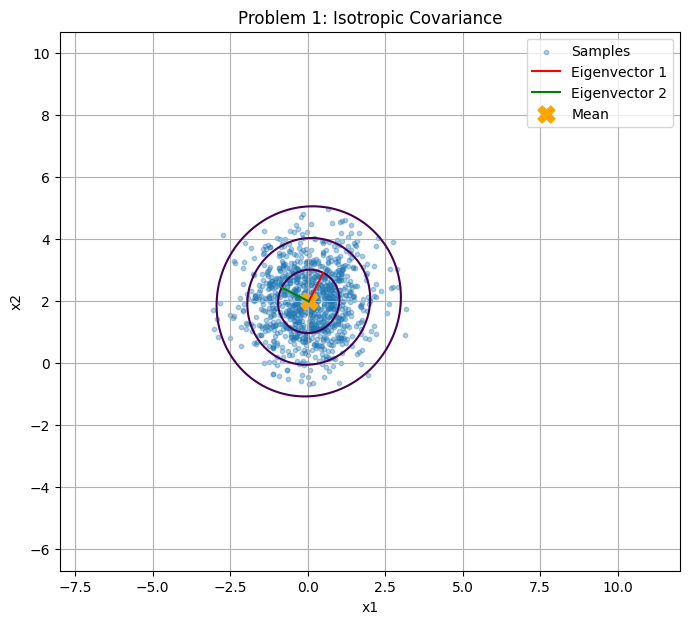


 Problem 1: Isotropic Covariance
Mean: [0.03111939 1.99530758]
Covariance:
 [[0.9817072  0.04322949]
 [0.04322949 1.04451261]]
Eigenvalues: [1.06654135 0.95967846]
Eigenvectors:
 [[ 0.45402666 -0.8909881 ]
 [ 0.8909881   0.45402666]]


In [ ]:
# =======================================
# PROBLEM 1: ISOTROPIC COVARIANCE
# =======================================

mu = np.array([0, 2])

cov = np.array([
    [1, 0],
    [0, 1]
])

X1 = generate_data(mu, cov, n)

plot_gaussian(
    X1,
    "Problem 1: Isotropic Covariance"
)

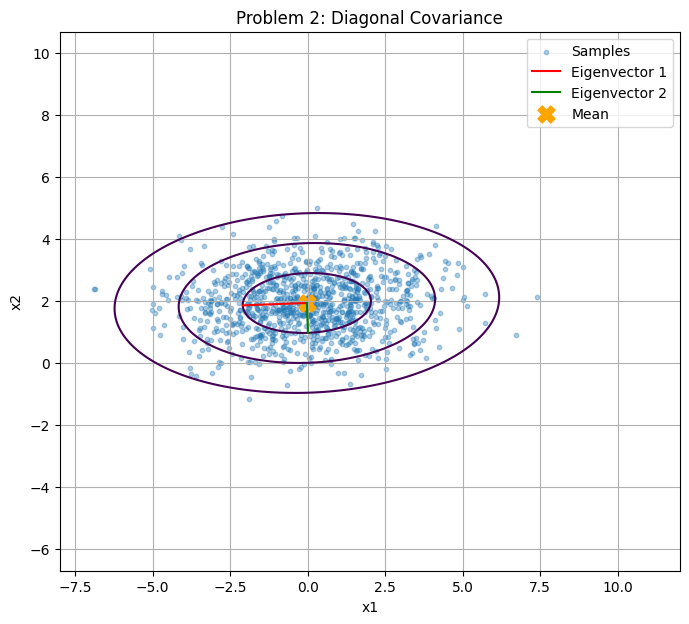


 Problem 2: Diagonal Covariance
Mean: [-0.02921328  1.9431276 ]
Covariance:
 [[4.27600955 0.12355251]
 [0.12355251 0.93512036]]
Eigenvalues: [4.28057253 0.93055738]
Eigenvectors:
 [[-0.99931873  0.03690632]
 [-0.03690632 -0.99931873]]


In [ ]:
# =======================================
# PROBLEM 2: DIAGONAL COVARIANCE
# =======================================

mu = np.array([0, 2])

cov = np.array([
    [4, 0],
    [0, 1]
])

X2 = generate_data(mu, cov, n)

plot_gaussian(
    X2,
    "Problem 2: Diagonal Covariance"
)

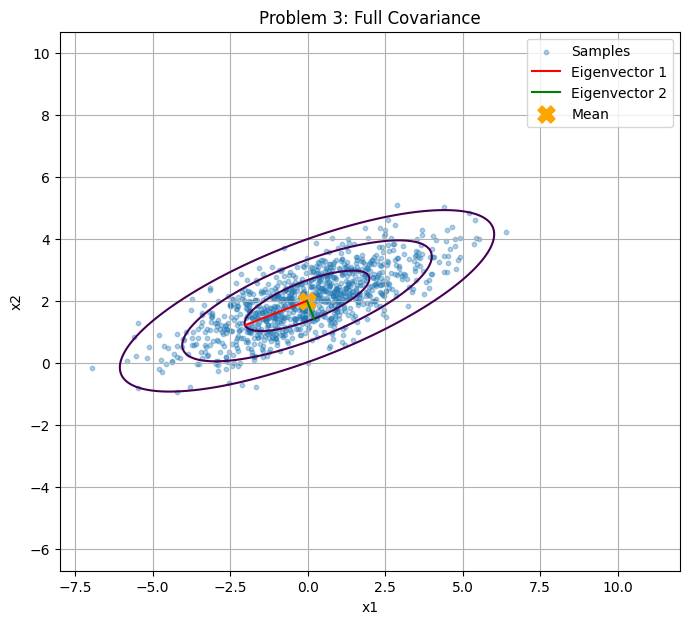


 Problem 3: Full Covariance
Mean: [-0.02446997  2.01233093]
Covariance:
 [[4.05059472 1.44191981]
 [1.44191981 0.95208776]]
Eigenvalues: [4.61778143 0.38490105]
Eigenvectors:
 [[-0.93059365  0.36605389]
 [-0.36605389 -0.93059365]]


In [ ]:
# =======================================
# PROBLEM 3: FULL COVARIANCE
# =======================================

mu = np.array([0, 2])

cov = np.array([
    [4, 1.5],
    [1.5, 1]
])

X3 = generate_data(mu, cov, n)

plot_gaussian(
    X3,
    "Problem 3: Full Covariance"
)

In [ ]:
# =======================================
# PROBLEM 4: DECISION BOUNDARY
# =======================================

def plot_boundary(mu1, cov1, mu2, cov2, title):

    Y1 = generate_data(mu1, cov1, n)

    Y2 = generate_data(mu2, cov2, n)

    x = np.linspace(-8, 14, 300)
    y = np.linspace(-6, 12, 300)

    Xgrid, Ygrid = np.meshgrid(x, y)

    points = np.stack([
        Xgrid,
        Ygrid
    ], axis=-1)

    inv1 = np.linalg.inv(cov1)
    inv2 = np.linalg.inv(cov2)

    det1 = np.linalg.det(cov1)
    det2 = np.linalg.det(cov2)

    p1 = (
        np.exp(
            -0.5 * np.einsum(
                "...i,ij,...j->...",
                points - mu1,
                inv1,
                points - mu1
            )
        )
        / (2 * np.pi * np.sqrt(det1))
    )

    p2 = (
        np.exp(
            -0.5 * np.einsum(
                "...i,ij,...j->...",
                points - mu2,
                inv2,
                points - mu2
            )
        )
        / (2 * np.pi * np.sqrt(det2))
    )

    decision = p1 - p2

    plt.figure(figsize=(9, 7))

    plt.scatter(
        Y1[:, 0],
        Y1[:, 1],
        s=10,
        alpha=0.35,
        label="Class 1"
    )

    plt.scatter(
        Y2[:, 0],
        Y2[:, 1],
        s=10,
        alpha=0.35,
        label="Class 2"
    )

    plt.contour(
        Xgrid,
        Ygrid,
        decision,
        levels=[0],
        linewidths=2
    )

    plt.scatter(
        mu1[0],
        mu1[1],
        marker="X",
        s=150,
        label="Mean 1"
    )

    plt.scatter(
        mu2[0],
        mu2[1],
        marker="X",
        s=150,
        label="Mean 2"
    )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.axis("equal")
    plt.show()

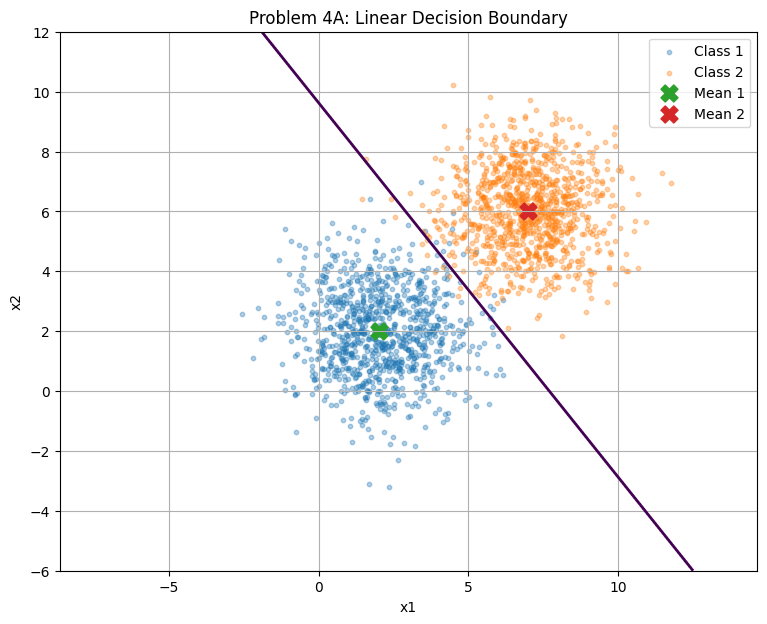

In [ ]:
# ---------------------------------------
# 4A: Linear Boundary
# Different Means, Same Covariance
# ---------------------------------------

mu1 = np.array([2, 2])
mu2 = np.array([7, 6])

cov1 = np.array([
    [2, 0],
    [0, 2]
])

cov2 = np.array([
    [2, 0],
    [0, 2]
])

plot_boundary(
    mu1,
    cov1,
    mu2,
    cov2,
    "Problem 4A: Linear Decision Boundary"
)

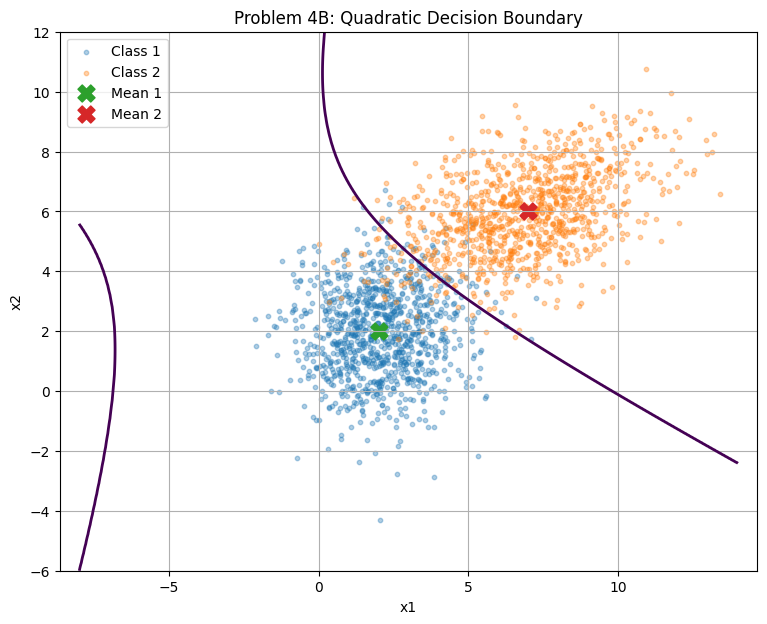

In [ ]:
# ---------------------------------------
# 4B: Quadratic Boundary
# Different Means, Different Covariance
# ---------------------------------------

mu1 = np.array([2, 2])
mu2 = np.array([7, 6])

cov1 = np.array([
    [2, 0],
    [0, 2]
])

cov2 = np.array([
    [5, 1.5],
    [1.5, 2]
])

plot_boundary(
    mu1,
    cov1,
    mu2,
    cov2,
    "Problem 4B: Quadratic Decision Boundary"
)

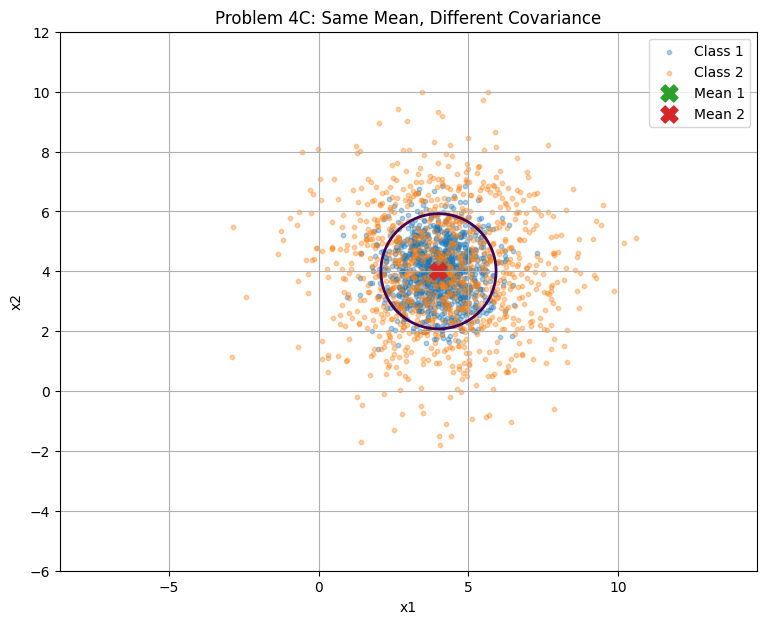

In [ ]:
# ---------------------------------------
# 4C: Same Means, Different Covariance
# Nonlinear Boundary
# ---------------------------------------

mu1 = np.array([4, 4])
mu2 = np.array([4, 4])

cov1 = np.array([
    [1, 0],
    [0, 1]
])

cov2 = np.array([
    [4, 0],
    [0, 4]
])

plot_boundary(
    mu1,
    cov1,
    mu2,
    cov2,
    "Problem 4C: Same Mean, Different Covariance"
)